# SBI_18 practice

Until now we have been doing the docking runs without providing __any information__ on what could be the potential interface mediating the interaction between proteins (FTDock and Zdock and also PAtchDock). This is known as __ab initio__ or __unbiased docking__. And by using PyDock to rescore our models. However, sometimes we have some information of regions that could be part of the interface. As described in the theorical lecture, the source of this information can vary from information of mutations that can
affect the interaction of proteins to analyses of evolutionary conservation.

The goal of this practical therefore to work on this specific aspect of docking, meaning to perform __data-driven__ or __biased docking__. We will include additional information in the form of specific residues, i.e. restraints, that will guide the docking simulation. We will learn how to perform data-driven docking procedures in _PatchDock_ and _pyDock_, and we will use it to __recalculate the docking__, scoring and refinement simulations performed in Practical SBI-17 (usig the same protein complxes as last practical).


## 1. Distance-restraints using pyDock on TolB-Pal complex
In this exercise, we will further analyze the docking calculations of _TolB_ (PDB code 1C5K) (in the xternal mbm of E.coli,important for antibiotic resistance) and unbound _Pal_ (PDB code 1OAP), which we already performed in Practical SBI-17.

To carry out the exercise you need all the files previously generated (T26*) . We will apply __distance restraints__ to filter docking results from already scored poses using the __energy-based function of pyDock__. The distance restraints will be extracted from scientific literature to simulate a real case situation often faced when predicting the structure of protein complex using docking. 

## 1.1. Data-based distance restraints to filter docking poses
In order to help you in choosing the best models from the starting pool of solutions, you can __complement pyDock energy-based ranking with distance restraints derived from experimental data__. In the following section: "Experimental data available”, there are extracts from a real scientific publication: Ray et al. (2000) Identification by genetic suppression of Escherichia coli TolB residues important for TolB-Pal interaction. J Bacteriol 2000; 182: 821-824. In these extracts, you will need to select the residues you think might be located at the interface and use them as distance restraints.

- Which mutations are impotant for the interaction? Which are in the TolB and Pal?
Pal: A88, P94, S126, G128 --> defect in TolB-PAl interaction
    Pal A88 : S99, E102 (intragenic supressor mutations)

If Pal has A88V it fixed the TolB mutations 

TolB: H246, A249, T292 (three tolB point mutations) affecting TOlB
All the extraeni supressor mutations of pal A88V are located in the C-t region of TolB, suggesting this region is impotant for its interaction with Pal. 


Intragenic supression (in the same gene) extragenic mutation (in a different gene) at all this mutation affects the overall phenotype. 

### 1.1.1 Include distance restrains in pyDock ini file
Experimental data restraints must be included on a new line of the “*.ini” file as for example:

`restr = A.Arg.36`

The restr keyword indicates to pyDock that distance restraint(s) will be used. A distance restraint defined from a given putative interface residue is considered satisfied when the center of coordinates of its side-chain lies within a distance of 6 Å from any non hydrogen atom of the partner molecule.
The restraint residue is defined by its chain name, its 3-letter residue code (first letter in uppercase), and its residue number, as found in the molecule file used in docking. When more than one restraint residues are used, they must be separated by comas with no space, as in the following example:

```
gedit 1c5k.pdb (see the chain of the mutations)
gedit 1oap.pdb (go to residue 88, 94, 126, 128)
```

```
[receptor]
pdb = 1C5K.pdb
mol = A
newmol = A
restr = A.His.246,A.Ala.249,A.Thr.292
[ligand]
pdb = 1OAP.pdb
mol = A
newmol = B
restr = A.Ala.88,A.Phe.94,A.Ser.126.A.Gly.1288
```
Be careful, this example is only indicative to understand how restraint(s) must be included. You have to include in the `T26.ini` file the experimental restraint(s) of your choice.

We know that this regions interact, and we force mutations in this region. 

### 1.1.2 Include distance restrains using pyDockRST
The restraints are applied to the docking poses using the pyDockRST module. Make
sure you are in the same directory where you previously run the docking and the energy ranking, i.e. location of the `T26.rot` and `T26.ene`(energy files) files. To run the corresponding module, simply issue the following command in a single line:

`pyDock3 T26 dockrst > dockrst.log &`

This run takes only a few minutes. It will compute distance restraints for all the docking models in T26.rot. Once completed you show have two additional files: `T26.eneRST` and `T26.rst` . 

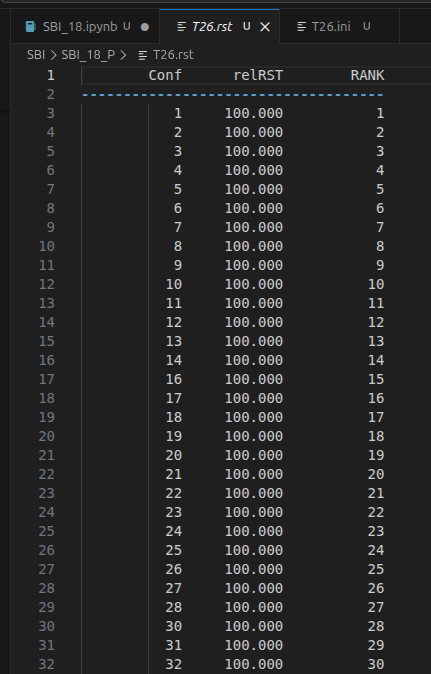

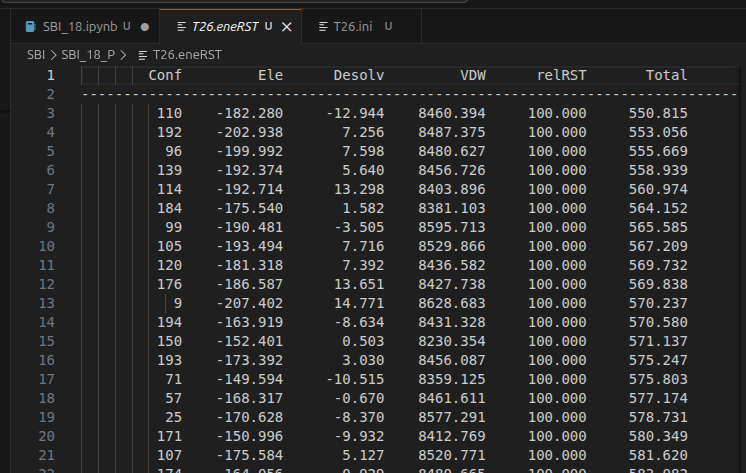

relRST are the restraints. 

The best in the `T26.rst` file, Each of this rows is a conformation, and 100% is 7 out of 7 applied restrains. All this restraints mutations if it is 100% that will means that good job.I s anew score in the Total soring function, not only look at the RMSD, but also this new score. 

These are text files, using your favorite text editor take a look at them and check how the experimental restraints affected the ranking of the original docking
poses. The `T26.eneRST` file is the original T26.ene energy file (previously created for docking models in T26.rot) combined with the restraint-based energy and ranked according to this new score. The way the satisfied restraints are converted to energy is just by multiplying by -1.0 and added to the final scoring function in the `T26.eneRST`

## 1.2. Analyze filtered docking poses
As before you will need to analyze the results by opening in chimera the top ranking
poses as per the new ranking that include distance restraints. Particularly, do consider whether the inclusion of distance restraints do improve the results. To that end you should consider for instance the comparison of the RMSD between the best nearnative docking models before and after applying the restraints.


# 2. Including binding site restraints in PatchDock on Savinase-BASI complex
We will __recalculate the rigid-body docking__ and refinement that we already performed with PatchDock in SBI-17 practical __on savinase-BASI complex__ but restraining the simulations by including information on the binding sites. As described in the previous practical, savinase is a protease and BASI is a competitive inhibitor. So, it is sensible to think on using this information to guide the docking of the savinase and BASI.

## 2.1. PatchDock Rigid docking with restraints
You should have the PDB files needed for this exercise from SBI-17 Practical:
• `savinase.pdb` - The structure of the protease in PDB format (chain A).
• `BASI.pdb` - The structure of the inhibitor in PDB format (chain C).
• `NativeComplex.pdb` - The structure of the correct native complex (PDB 3bx1).

### 2.1.1. Prepare the restraints files for PatchDock
You need to prepare two different files containing restraints for both savinase
(receptor) and BASI (ligand). Please consider the following:

```
Savinase has a catalytic triad consisting of Asp32, His64 and Ser221, situated in a shallow groove on the surface. In addition, a low-resolution structure of a homologue of BASI (WASI) in a complex with proteinase K has indicated an important role of a loop (residues from 85 to 96) in the inhibition process.
```
If BASI is a competititive inhibitor of this protease, it will bind in the catalytic site. So we want BASI to be close to this restraints. 

_SAVINASE: Asp.32, His.64, Ser.221_

Proteinase K homolog to savinase
WASI homolog to BASI, and has a loop between 85-96 important for the inhibition process. 

To know which particular region interaction in WASI, open the struture of WASI in pymol. As we only have BASI, and is a homolog of WASI, we could asusme that this region of BASI being the same in WASI. (pymol > c > by ss> color by secondary structure). To test if they look alike, we would have to align them first!. 

_BASI: 85,86,87, 88, 89, 90, 91, 92. 93, 94, 95, 96_


How do we tell patchdock to use this information to drive the docking?


Now, based on this information prepare two binding site files according to the biological information provided above. For instance, the binding site file for the receptor (savinase) can be named `s1.txt` (contain restraints for savinase) and will contain two columns, the first with the numbers of the residues that are expected to be at the interface, and a second column with the chain IDs of such residues, like:

```
32 A
64 A
221 A
```

You will need to create another file for the ligand binding site (e.g. `s2.txt`) with similar format for the ligand (BASI), according to the biological knowledge provided above.

```
85 C
86 C
87 C
88 C
89 C
90 C
91 C
92 C
93 C
94 C
95 C
96 C
```
Both *.txt files contians the restraints we want to impose in this docking. 

### 2.1.2. Run PatchDock with restraints
Firstly, we need to generate the parameter files (`params.txt`) as previously shown
in the previous session. Note, that you could re-use the one you generated previously.
In any case, to general this file, issue the following command

`buildParams.pl savinase.pdb BASI.pdb 4.0 EI`
EI = Enzyme-Inhibitor complex

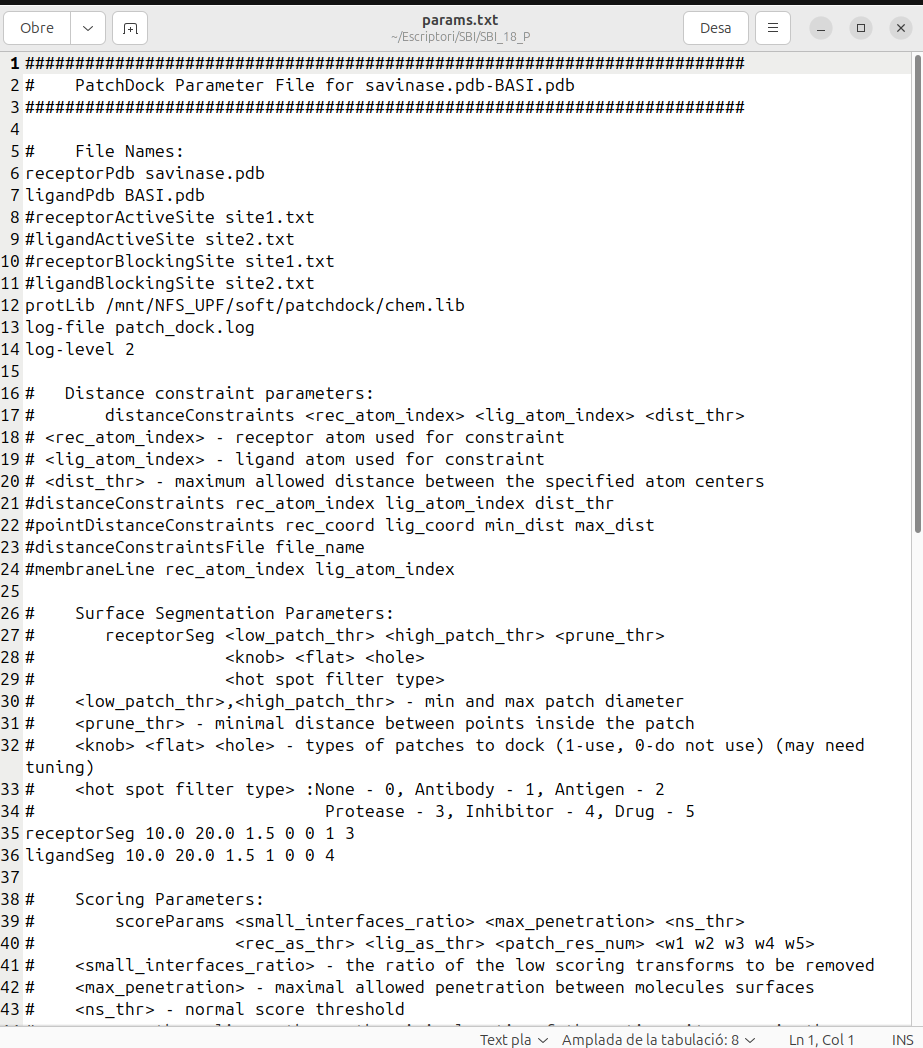


The parameter file (params.txt) include all the information for PatchDock. We need
to _modify this file to include the information of the binding sites_. To do that open the file with your favorite text editor. Locate the following lines starting with:

Line nº8 and 9 are ignored (bcause contins #, so have to eliminate them), this is common on Linux. And this is impotant because this files will contain info about our restraints. Also change the name of the file to s1.txt ad s2.txt. 10-11 are blocking sites, info of regions that are not part of the itnerface, for instance, image we have not a binary but a tertiary complex (3 instead of 2), and the region between A-C, only matters between these two, not for B, so this info will be in the blocking site, not in the active site. 

Save and close both files. Now you can run PatchDock to perform the docking with
contraints issuing the following command:

`patch_dock.Linux params.txt out_file3`